# Phase 3 — Feature Engineering
**Goal:** Transform raw match data into model-ready features. Produce three processed files that all downstream models will use.

**Outputs:**
- `data/processed/matches_clean.csv` — 32,012 historical matches with ML features
- `data/processed/team_features.csv` — current snapshot of all 246 active teams
- `data/processed/portugal_path.csv` — Portugal's 2026 bracket path


In [1]:
# Run the full feature engineering pipeline
# All logic lives in src/features.py
%run ../src/features.py

Loading raw data...


FileNotFoundError: [Errno 2] No such file or directory: 'data\\raw\\international_results.csv'

## Inspect: matches_clean.csv

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

mc = pd.read_csv('../data/processed/matches_clean.csv', parse_dates=['date'])
print(f'Shape: {mc.shape}')
print(f'Date range: {mc["date"].min().date()} to {mc["date"].max().date()}')
mc.head(3)

Shape: (32012, 20)
Date range: 1990-01-12 to 2026-03-31


,date,home_team,away_team,home_score,away_score,result,neutral_ground,tournament,tournament_type,home_elo,away_elo,elo_diff,home_avg_scored,home_avg_conceded,home_form,away_avg_scored,away_avg_conceded,away_form,h2h_home_win_rate,h2h_total_matches
0,1990-01-12,Algeria,Mali,5.0,0.0,W,1,Friendly,Friendly,1709.0,1404.0,305.0,NaN,NaN,NaN,NaN,NaN,NaN,0.529412,17
1,1990-01-14,Algeria,Cameroon,3.0,1.0,W,1,Friendly,Friendly,1709.0,1700.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,0.272727,11
2,1990-01-17,Mexico,Argentina,2.0,0.0,W,1,Friendly,Friendly,1894.0,1839.0,55.0,NaN,NaN,NaN,NaN,NaN,NaN,0.100000,20


In [3]:
# Feature completeness
feat_cols = ['home_elo','away_elo','elo_diff','home_avg_scored','home_avg_conceded',
             'home_form','away_avg_scored','away_avg_conceded','away_form','h2h_home_win_rate']
nan_pct = mc[feat_cols].isna().mean() * 100
print('Feature NaN %:')
print(nan_pct.round(1).to_string())

Feature NaN %:
home_elo              8.3
away_elo              8.9
elo_diff             14.4
home_avg_scored       2.0
home_avg_conceded     2.0
home_form             4.2
away_avg_scored       2.2
away_avg_conceded     2.2
away_form             4.5
h2h_home_win_rate     0.0


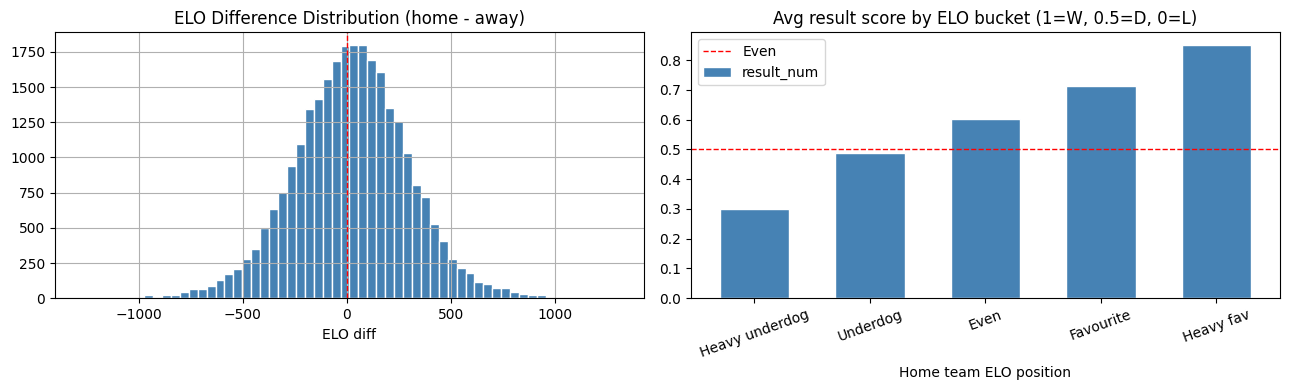

In [4]:
# ELO diff distribution — key feature for all three models
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
mc['elo_diff'].dropna().hist(bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('ELO Difference Distribution (home - away)')
axes[0].set_xlabel('ELO diff')
axes[0].axvline(0, color='red', lw=1, ls='--')

# ELO diff vs result
mc['result_num'] = mc['result'].map({'W': 1, 'D': 0.5, 'L': 0})
mc['elo_bucket'] = pd.cut(mc['elo_diff'].dropna(), bins=[-600,-200,-50,50,200,600],
                           labels=['Heavy underdog','Underdog','Even','Favourite','Heavy fav'])
win_by_bucket = mc.groupby('elo_bucket', observed=True)['result_num'].mean()
win_by_bucket.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white', width=0.6)
axes[1].set_title('Avg result score by ELO bucket (1=W, 0.5=D, 0=L)')
axes[1].set_xlabel('Home team ELO position')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20)
axes[1].axhline(0.5, color='red', lw=1, ls='--', label='Even')
axes[1].legend()
plt.tight_layout()
plt.savefig('../outputs/charts/08_elo_diff_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Inspect: team_features.csv

In [5]:
tf = pd.read_csv('../data/processed/team_features.csv')
print(f'Teams: {len(tf)}')
print('\nTop 15 by ELO:')
print(tf.head(15)[['team','elo_rating','avg_goals_scored','avg_goals_conceded','form_index']].to_string(index=False))

Teams: 246

Top 15 by ELO:
       team  elo_rating  avg_goals_scored  avg_goals_conceded  form_index
      Spain      2171.0              2.75                1.00    0.763636
  Argentina      2113.0              2.00                0.50    0.818182
     France      2062.0              2.00                1.00    0.836364
    England      2042.0              2.35                0.55    0.763636
   Colombia      1998.0              1.90                0.95    0.581818
     Brazil      1979.0              1.60                0.90    0.381818
   Portugal      1976.0              2.10                1.00    0.490909
Netherlands      1959.0              2.65                1.00    0.763636
    Ecuador      1933.0              0.90                0.35    0.254545
    Croatia      1933.0              2.05                1.05    0.872727
     Norway      1922.0              3.00                0.95    0.690909
    Germany      1910.0              2.40                1.05    0.818182
Switzerland

In [6]:
# Group K teams
group_k = ['Portugal', 'Colombia', 'Uzbekistan', 'DR Congo']
elo_name_map = {'DR Congo': 'Democratic Republic of Congo'}
group_k_lookup = [elo_name_map.get(t, t) for t in group_k]
k_feats = tf[tf['team'].isin(group_k + group_k_lookup)].copy()
print('Group K features:')
print(k_feats[['team','elo_rating','avg_goals_scored','avg_goals_conceded','form_index']].to_string(index=False))

Group K features:
                        team  elo_rating  avg_goals_scored  avg_goals_conceded  form_index
                    Colombia      1998.0               1.9                0.95    0.581818
                    Portugal      1976.0               2.1                1.00    0.490909
                  Uzbekistan      1735.0               1.5                0.65    0.490909
Democratic Republic of Congo      1616.0               NaN                 NaN         NaN


## Inspect: portugal_path.csv

In [7]:
pp = pd.read_csv('../data/processed/portugal_path.csv')
print(pp.to_string(index=False))

        stage                fixture     type                                  notes
  Group Stage   Portugal vs DR Congo    group              Group K, Match 1 — Jun 17
  Group Stage Portugal vs Uzbekistan    group              Group K, Match 2 — Jun 23
  Group Stage   Colombia vs Portugal    group              Group K, Match 3 — Jun 27
  Round of 32        Portugal vs TBD knockout Opponent = best 3rd-place from bracket
  Round of 16        Portugal vs TBD knockout           Winner of adjacent R32 match
Quarter-Final        Portugal vs TBD knockout                                    TBD
   Semi-Final        Portugal vs TBD knockout                                    TBD
        Final        Portugal vs TBD knockout                                    TBD


## Feature correlation with match outcome

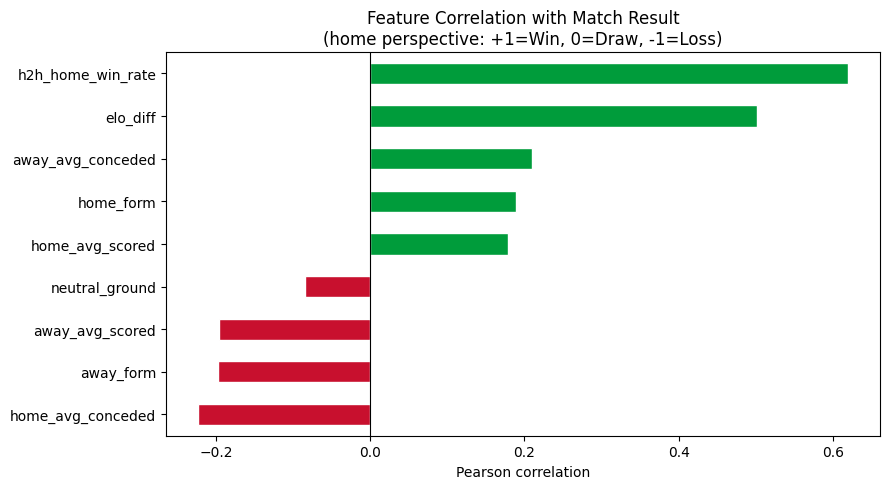

home_avg_conceded   -0.223
away_form           -0.197
away_avg_scored     -0.197
neutral_ground      -0.085
home_avg_scored      0.179
home_form            0.188
away_avg_conceded    0.210
elo_diff             0.502
h2h_home_win_rate    0.619


In [8]:
mc['result_num'] = mc['result'].map({'W': 1, 'D': 0, 'L': -1})
feat_cols = ['elo_diff','home_avg_scored','home_avg_conceded','home_form',
             'away_avg_scored','away_avg_conceded','away_form','h2h_home_win_rate','neutral_ground']
corr = mc[feat_cols + ['result_num']].corr()['result_num'].drop('result_num').sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#C8102E' if v < 0 else '#009C3B' for v in corr.values]
corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Feature Correlation with Match Result\n(home perspective: +1=Win, 0=Draw, -1=Loss)', fontsize=12)
ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.savefig('../outputs/charts/09_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(corr.round(3).to_string())